<a href="https://colab.research.google.com/github/Riya-Verma123/computer_vision_lab_files/blob/main/labsheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from google.colab import files

Saving download (30).jpg to download (30).jpg


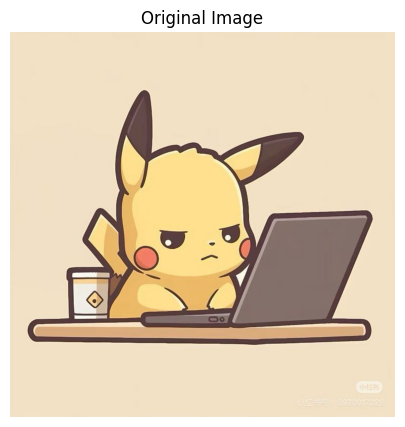

In [3]:
uploaded = files.upload()

image_path = next(iter(uploaded))
img = cv2.imread(image_path)

# Convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

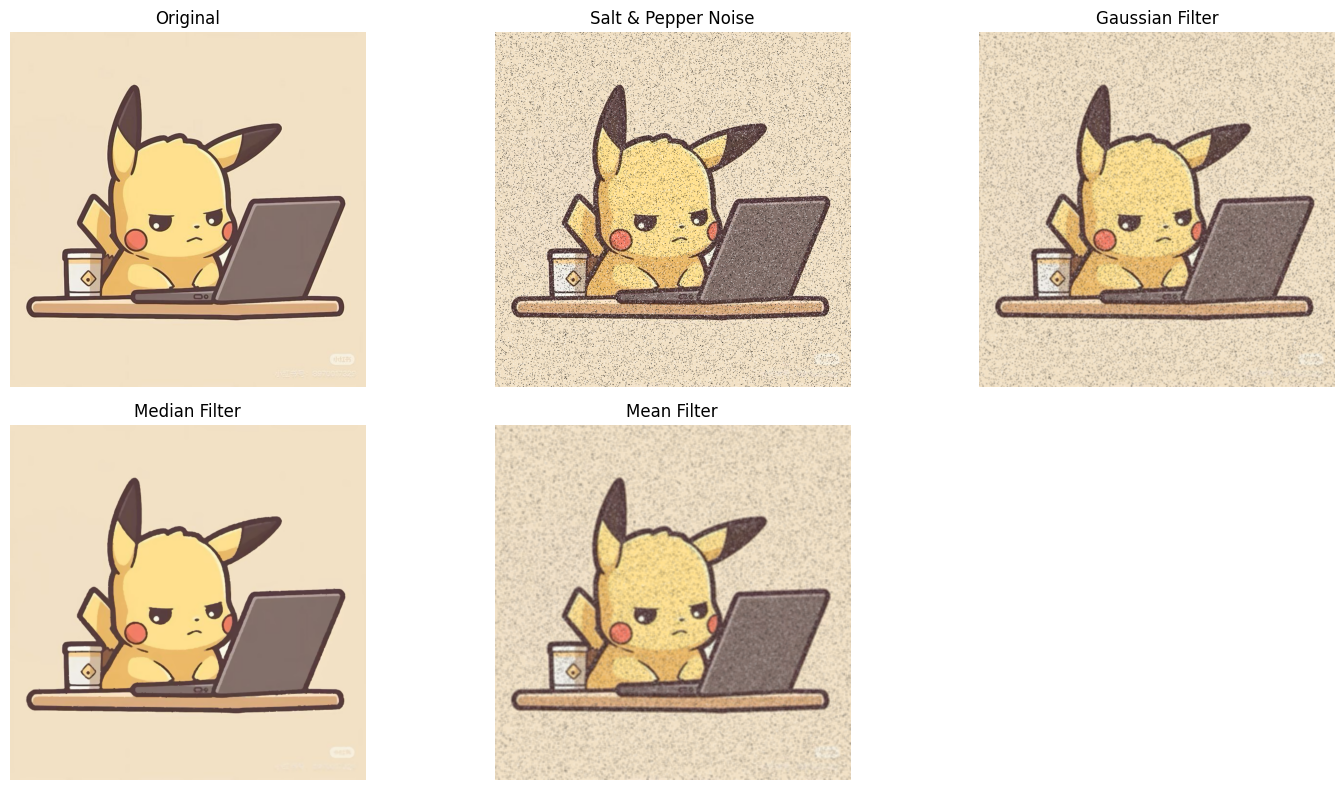

In [4]:
# Add salt-and-pepper noise
def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()

    num_pixels = int(amount * image.shape[0] * image.shape[1])

    # Salt noise
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 255

    # Pepper noise
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 0

    return noisy


# Add noise
noisy = add_salt_pepper_noise(img_rgb)

# Gaussian filter
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

# Median filter
median = cv2.medianBlur(noisy, 5)

# Mean filter
mean = cv2.blur(noisy, (5, 5))


# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy)
plt.title("Salt & Pepper Noise")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(median)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mean)
plt.title("Mean Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

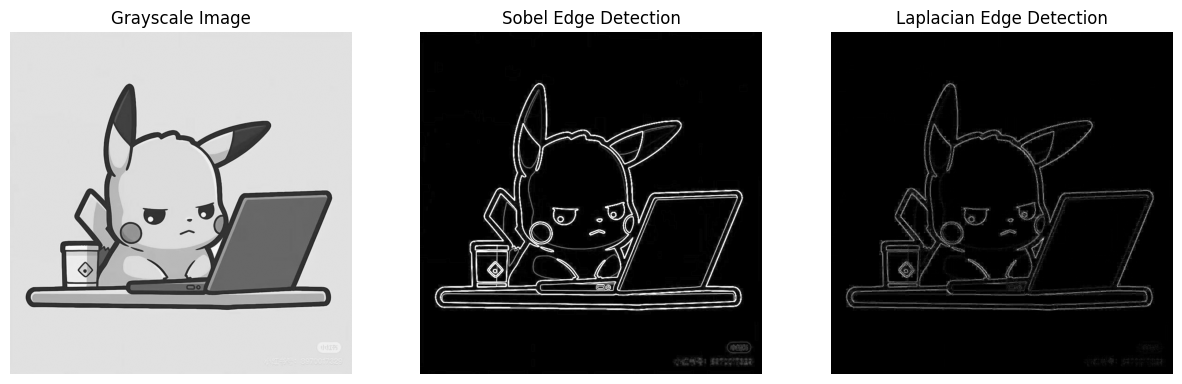

In [5]:
# Convert image to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Sobel X
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

# Sobel Y
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Combine Sobel X and Y
sobel = cv2.magnitude(sobel_x, sobel_y)

# Laplacian
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convert to displayable format
sobel = cv2.convertScaleAbs(sobel)
laplacian = cv2.convertScaleAbs(laplacian)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Edge Detection")
plt.axis("off")

plt.show()

In [6]:
import ipywidgets as widgets
from IPython.display import display

# Kernel size slider
kernel_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=21,
    step=2,
    description="Kernel:"
)

def apply_blur(kernel_size):
    blurred = cv2.GaussianBlur(
        img_rgb,
        (kernel_size, kernel_size),
        0
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(blurred)
    plt.title(f"Gaussian Blur - Kernel Size: {kernel_size}")
    plt.axis("off")
    plt.show()


widgets.interact(apply_blur, kernel_size=kernel_slider);

interactive(children=(IntSlider(value=5, description='Kernel:', max=21, min=1, step=2), Output()), _dom_classe…

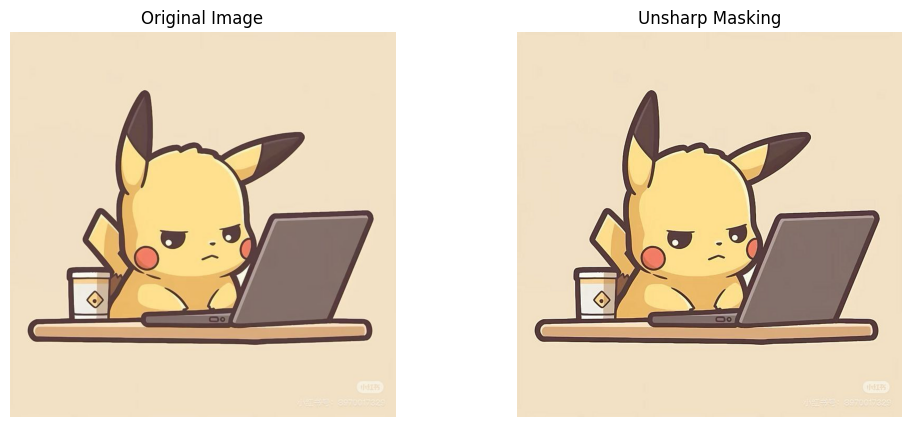

In [7]:
# Convert image to float
image_float = img_rgb.astype(np.float32)

# Create blurred image
blurred = cv2.GaussianBlur(image_float, (5, 5), 0)

# Unsharp masking
sharpened = cv2.addWeighted(
    image_float,
    1.5,
    blurred,
    -0.5,
    0
)

# Convert back to uint8
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title("Unsharp Masking")
plt.axis("off")

plt.show()

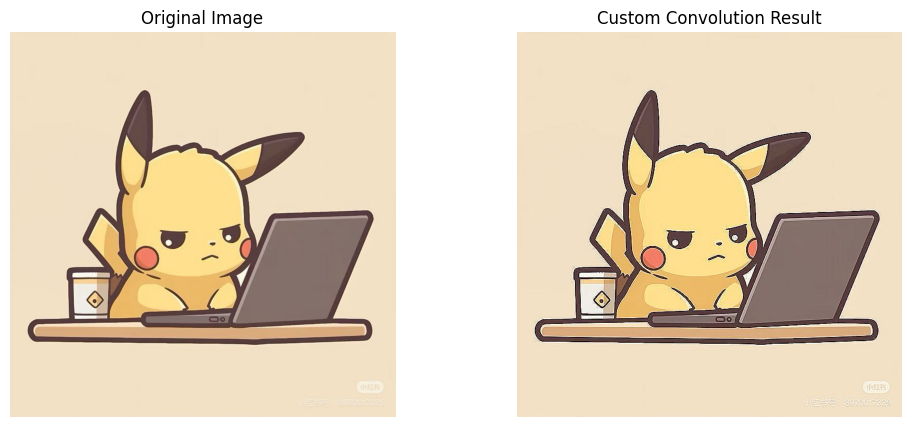

Custom Kernel:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


In [8]:
# Example custom sharpening kernel
kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)

# Apply custom convolution
custom_result = cv2.filter2D(
    img_rgb,
    -1,
    kernel
)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(custom_result)
plt.title("Custom Convolution Result")
plt.axis("off")

plt.show()

print("Custom Kernel:")
print(kernel)

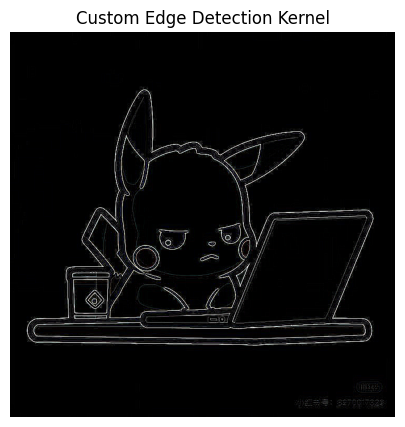

In [9]:
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

result = cv2.filter2D(img_rgb, -1, kernel)

plt.figure(figsize=(8, 5))
plt.imshow(result)
plt.title("Custom Edge Detection Kernel")
plt.axis("off")
plt.show()

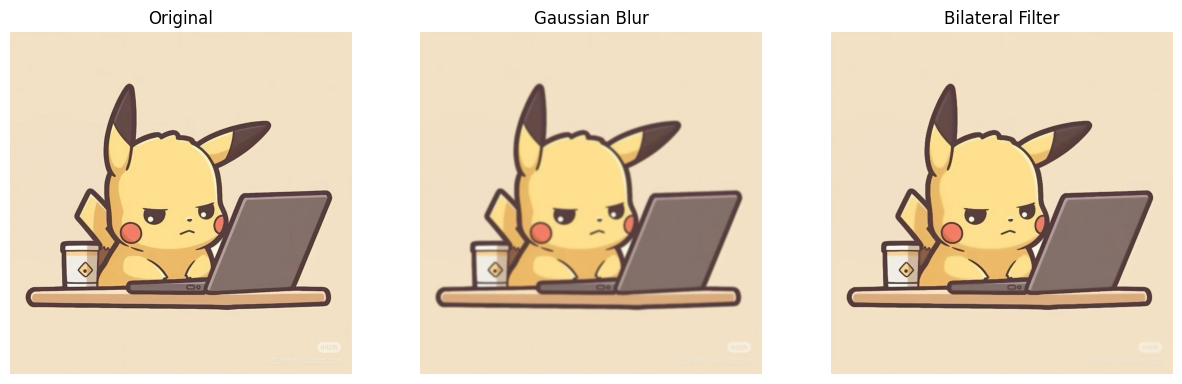

In [10]:
# Gaussian blur
gaussian = cv2.GaussianBlur(
    img_rgb,
    (9, 9),
    0
)

# Bilateral filtering
bilateral = cv2.bilateralFilter(
    img_rgb,
    9,
    75,
    75
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral)
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()

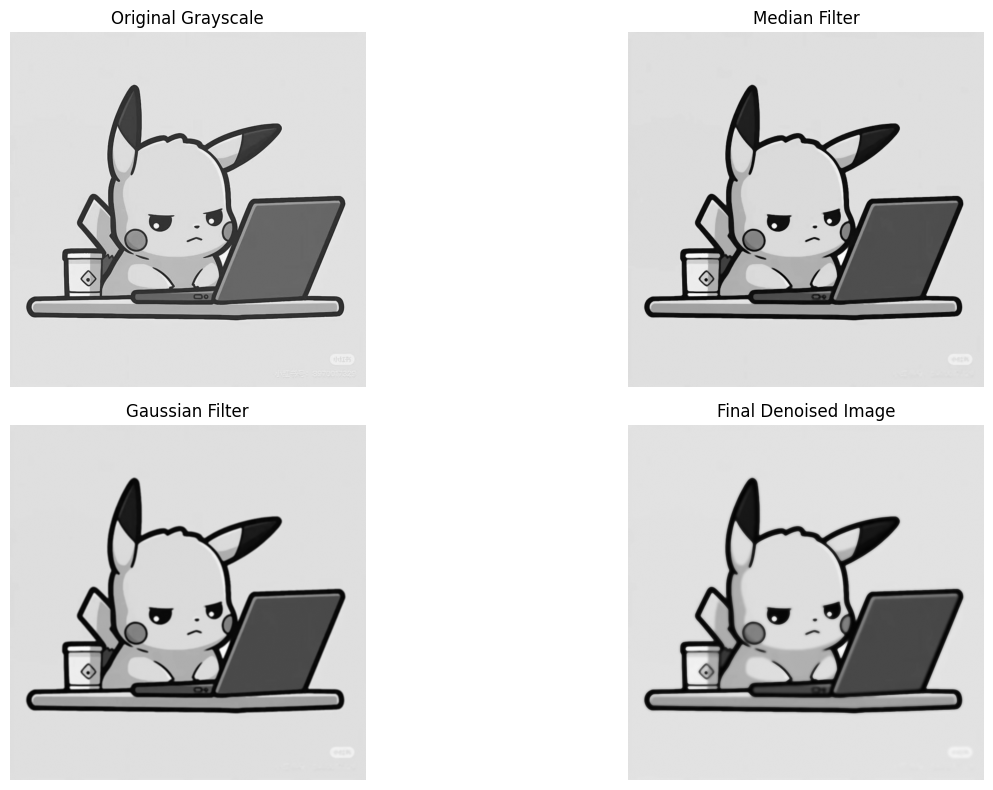

In [11]:
# Convert to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Step 1: Median filtering
median = cv2.medianBlur(gray, 5)

# Step 2: Gaussian smoothing
gaussian = cv2.GaussianBlur(median, (5, 5), 0)

# Step 3: Bilateral filtering
bilateral = cv2.bilateralFilter(
    gaussian,
    9,
    50,
    50
)

# Display pipeline
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bilateral, cmap="gray")
plt.title("Final Denoised Image")
plt.axis("off")

plt.tight_layout()
plt.show()

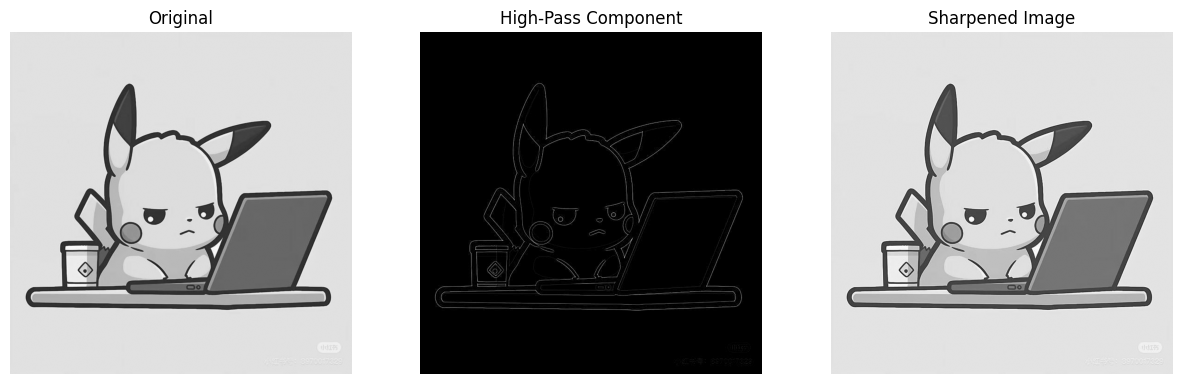

In [12]:
# Convert image to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Smooth image
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# High-pass component
high_pass = cv2.subtract(gray, blurred)

# Sharpen
sharpened = cv2.addWeighted(
    gray,
    1.5,
    blurred,
    -0.5,
    0
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(high_pass, cmap="gray")
plt.title("High-Pass Component")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")

plt.show()

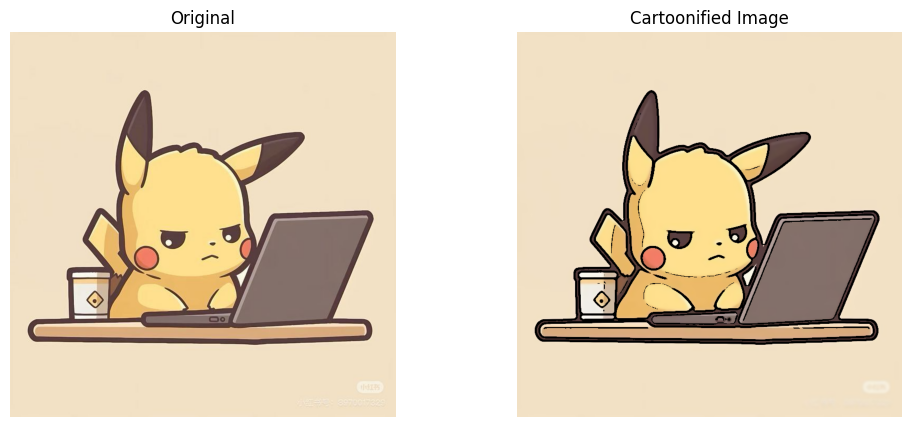

In [13]:
# Step 1: Smooth the image
smooth = cv2.bilateralFilter(
    img_rgb,
    9,
    75,
    75
)

# Step 2: Convert to grayscale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Step 3: Detect edges
edges = cv2.adaptiveThreshold(
    cv2.medianBlur(gray, 7),
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9,
    9
)

# Step 4: Combine edges with smoothed image
cartoon = cv2.bitwise_and(
    smooth,
    smooth,
    mask=edges
)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cartoon)
plt.title("Cartoonified Image")
plt.axis("off")

plt.show()

In [14]:
# Create noisy image
noisy = add_salt_pepper_noise(img_rgb, amount=0.05)

# Apply filters
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)
mean = cv2.blur(noisy, (5, 5))
bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

# Store results
results = {
    "Noisy": noisy,
    "Gaussian": gaussian,
    "Median": median,
    "Mean": mean,
    "Bilateral": bilateral
}

# Calculate metrics
print("Filtering Performance")
print("-" * 50)

for name, result in results.items():

    psnr_value = psnr(
        img_rgb,
        result,
        data_range=255
    )

    ssim_value = ssim(
        img_rgb,
        result,
        channel_axis=2,
        data_range=255
    )

    print(f"{name:10s} | PSNR: {psnr_value:.2f} dB | SSIM: {ssim_value:.4f}")

Filtering Performance
--------------------------------------------------
Noisy      | PSNR: 14.46 dB | SSIM: 0.1494
Gaussian   | PSNR: 23.29 dB | SSIM: 0.4127
Median     | PSNR: 33.32 dB | SSIM: 0.9719
Mean       | PSNR: 23.48 dB | SSIM: 0.5240
Bilateral  | PSNR: 14.63 dB | SSIM: 0.1702


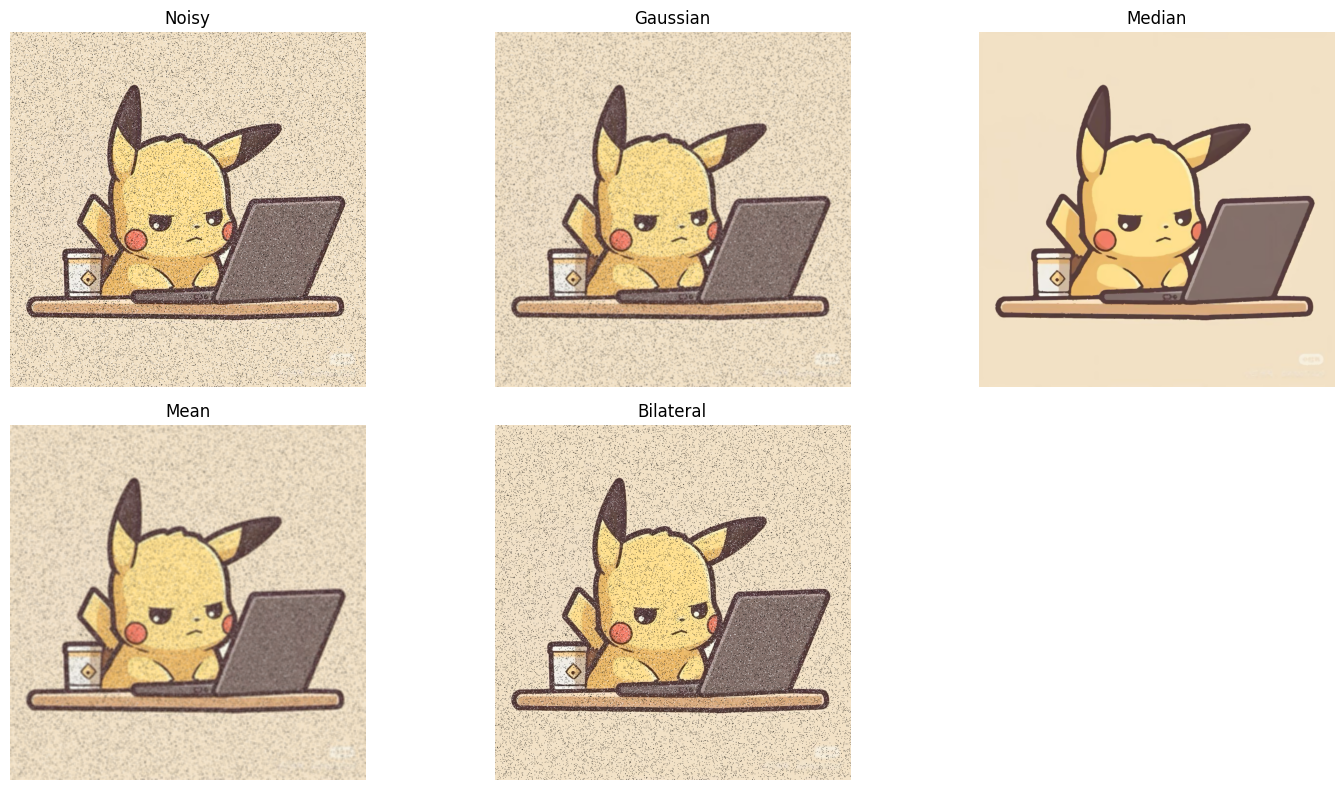

In [15]:
plt.figure(figsize=(15, 8))

names = list(results.keys())

for i, name in enumerate(names):

    plt.subplot(2, 3, i + 1)
    plt.imshow(results[name])
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()